# Imports

In [1]:
import cv2
import os
import numpy as np
from dataclasses import dataclass, field
from collections import deque
from typing import List, Tuple, Dict
import json
from ultralytics import YOLO
import matplotlib.pyplot as plt
import torch

# Preprocessing

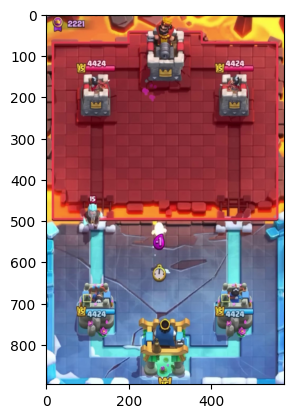

In [2]:
def crop_and_resize(input_img, target_width = 576, target_height = 896):
    img = input_img.copy()
    h, w, _ = img.shape
    target_aspect = target_width / target_height

    new_h = int(w / target_aspect)

    # how much im cutting off
    crop_total = h - new_h

    crop_top = crop_total // 2 - 100
    crop_bottom = crop_total - crop_top + 100

    y1 = crop_top
    y2 = h - crop_bottom
    x1 = 0
    x2 = w
    # get dimensions of current image
    # get target aspect ratio
    # determine new height and width of entire image BEFORE RESIZING
    # find dimensions to make cut - I only cut off the top and the bottom of the image. This requires some domain knowledge because I know the game occurs in the middle of the screen, so I don't need top and bottom. 
    # once you find the dimensions you need to cut, then perform the crop
    cropped = img[y1:y2, x1:x2]
    # resize
    resized = cv2.resize(cropped, (target_width, target_height), interpolation=cv2.INTER_AREA)
    return resized

img = cv2.imread("output_frames/sec_0020.jpg")
cropped_and_resized = crop_and_resize(img)
img_rgb = cv2.cvtColor(cropped_and_resized, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

In [3]:
def preprocess_video(input_vid_path, output_vid_path, target_width = 576, target_height=896):
    # open the video here
    cap = cv2.VideoCapture(input_vid_path)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    # set the ouput - i have a 30 fps video, and i know what i want the dimensions to be, so i can set those here.
    out = cv2.VideoWriter(output_vid_path, fourcc, 30.0, (target_width, target_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        processed_frame = crop_and_resize(frame, target_width, target_height)
        out.write(processed_frame)

    cap.release()
    out.release()
preprocess_video("./vids/hog_2_6_start.mp4", "output_video.mp4")

# Processing


image 1/1 /Users/michael/Documents/Codeology/clash_royacado/output_frames/sec_0020.jpg: 896x416 3 queen-towers, 5 selecteds, 1 text, 1 elixir, 1 skeleton, 2 electro-spirits, 1 dirt, 1 mortar, 1 pad_2, 28.5ms
Speed: 3.5ms preprocess, 28.5ms inference, 1.3ms postprocess per image at shape (1, 3, 896, 416)
Results saved to /Users/michael/Documents/Codeology/clash_royacado/runs/detect/predict32


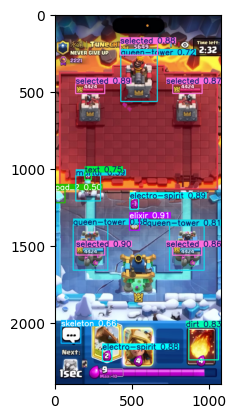

In [7]:
model = YOLO('./finetuned_clash.pt')
device = 'mps'
model = model.to("mps")

results = model.predict(
    source = "output_frames/sec_0020.jpg",
    save = True,
    imgsz = 896,
    conf = 0.5
)
plt.imshow(results[0].plot()[:, :, [2,1,0]])

# Postprocessing

Object Tracking

In [9]:
FPS = 30 # fps of the video we are using
PATIENCE_FRAMES = 60  # Frames to wait before closing a lost track

@dataclass
class TrackedObject:
    """
    Lean object to store track ID, class, and raw coordinate history.
    """
    track_id: int
    class_id: int
    start_frame: int
    
    positions: List[Tuple[float, float]] = field(default_factory=list)
    last_seen_frame: int = 0
    
    def update(self, position: Tuple[float, float], frame_id: int):
        self.positions.append(position)
        self.last_seen_frame = frame_id

    @property
    def duration_seconds(self) -> float:
        return (self.last_seen_frame - self.start_frame) / FPS

    @property
    def start_position(self) -> Tuple[float, float]:
        return self.positions[0] if self.positions else (0, 0)

    @property
    def end_position(self) -> Tuple[float, float]:
        return self.positions[-1] if self.positions else (0, 0)

    def to_dict(self):
        """Convert to standard Python types for JSON export."""
        return {
            "track_id": int(self.track_id),
            "class_id": int(self.class_id),
            "start_frame": int(self.start_frame),
            "end_frame": int(self.last_seen_frame),
            "duration_seconds": float(self.duration_seconds),
            "positions": [[float(x), float(y)] for x, y in self.positions]
        }

Game Tracking

In [10]:
class GameTracker:
    def __init__(self, patience_threshold=30):
        self.active_tracks: Dict[int, TrackedObject] = {}
        self.lost_counters: Dict[int, int] = {}
        self.completed_tracks: List[TrackedObject] = []
        self.patience = patience_threshold
    
    def update(self, tracks, frame_id: int):
        current_frame_track_ids = set()

        # 1. Update/Create Active Tracks
        for track in tracks:
            x1, y1, x2, y2 = track[0:4]
            track_id = int(track[6])
            class_id = int(track[5])
            
            centroid = ((x1 + x2) / 2, (y1 + y2) / 2)
            current_frame_track_ids.add(track_id)

            if track_id in self.active_tracks:
                self.active_tracks[track_id].update(centroid, frame_id)
                # Object found, reset lost counter
                if track_id in self.lost_counters:
                    del self.lost_counters[track_id]
            else:
                new_obj = TrackedObject(track_id, class_id, frame_id)
                new_obj.update(centroid, frame_id)
                self.active_tracks[track_id] = new_obj
        
        # 2. Handle Lost Tracks (Patience Buffer)
        active_ids = list(self.active_tracks.keys())
        for tid in active_ids:
            if tid not in current_frame_track_ids:
                self.lost_counters[tid] = self.lost_counters.get(tid, 0) + 1
                
                if self.lost_counters[tid] > self.patience:
                    finished_obj = self.active_tracks.pop(tid)
                    self.completed_tracks.append(finished_obj)
                    del self.lost_counters[tid]

    def finalize(self):
        """Push all remaining active tracks to completed."""
        for obj in self.active_tracks.values():
            self.completed_tracks.append(obj)
        self.active_tracks.clear()
        self.lost_counters.clear()

    def save_to_json(self, filename="game_tracking_data.json"):
        """Export all completed tracking data."""
        data = {
            "metadata": {
                "total_tracks": len(self.completed_tracks),
                "patience_setting": self.patience
            },
            "tracks": [t.to_dict() for t in self.completed_tracks]
        }
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
        print(f"Data successfully saved to {filename}")

Control Loop: Model Tracking and Processing

In [18]:
# Initialize our tracker
tracker = GameTracker(patience_threshold=PATIENCE_FRAMES)

# Run inference with ByteTrack
results = model.track(
    source='output_video.mp4',
    save=True,
    imgsz=896,
    conf=0.5,
    project='vids',
    name='hog_2_6_results_clean',
    exist_ok=True,
    tracker="bytetrack.yaml",
    stream=True,
    show_labels=False,
    persist = True
)

print(f"Processing Video with Patience={PATIENCE_FRAMES}...")

for frame_idx, result in enumerate(results):
    boxes = result.boxes
    if boxes.id is None:
        continue

    # Extract tensors to flat lists
    xyxy = boxes.xyxy.cpu().numpy()
    ids = boxes.id.cpu().numpy()
    conf = boxes.conf.cpu().numpy()
    cls = boxes.cls.cpu().numpy()
    
    detections = []
    for (box, track_id, score, class_id) in zip(xyxy, ids, conf, cls):
        x1, y1, x2, y2 = box
        
        detection_entry = [
            float(x1),
            float(y1),
            float(x2),
            float(y2),
            float(score),
            int(class_id),
            int(track_id)
        ]
        
        detections.append(detection_entry)
    # Send to GameTracker
    tracker.update(detections, frame_id=frame_idx)

# Force close tracks at the end of the video
tracker.finalize()
print("Processing Complete.")

Processing Video with Patience=60...

video 1/1 (frame 1/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x576 2 king-towers, 4 queen-towers, 4 selecteds, 187.8ms
video 1/1 (frame 2/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x576 2 king-towers, 4 queen-towers, 4 selecteds, 1 emote, 1 text, 1 freeze, 31.7ms
video 1/1 (frame 3/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x576 2 king-towers, 4 queen-towers, 4 selecteds, 1 emote, 1 text, 1 freeze, 24.6ms
video 1/1 (frame 4/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x576 2 king-towers, 4 queen-towers, 4 selecteds, 1 emote, 1 text, 1 freeze, 26.3ms
video 1/1 (frame 5/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x576 2 king-towers, 4 queen-towers, 4 selecteds, 1 emote, 1 text, 1 freeze, 24.3ms
video 1/1 (frame 6/265) /Users/michael/Documents/Codeology/clash_royacado/output_video.mp4: 896x57

In [19]:
def print_summary(tracker_obj):
    print(f"{'ID':<5} {'Class':<10} {'Duration (s)':<15} {'Start Pos':<20} {'End Pos':<20} {'Avg Vel (px/f)'}")
    print("-" * 90)
    for obj in tracker_obj.completed_tracks:
        # Calculate global velocity here instead of live
        if len(obj.positions) > 1:
            start_arr = np.array(obj.start_position)
            end_arr = np.array(obj.end_position)
            total_disp = np.linalg.norm(end_arr - start_arr)
            total_frames = obj.last_seen_frame - obj.start_frame
            global_avg_vel = total_disp / total_frames if total_frames > 0 else 0
        else:
            global_avg_vel = 0
            
        print(f"{obj.track_id:<5} {obj.class_id:<10} {obj.duration_seconds:<15.2f} "
              f"{str(tuple(map(int, obj.start_position))):<20} "
              f"{str(tuple(map(int, obj.end_position))):<20} "
              f"{global_avg_vel:.2f}")

# Print Table
print_summary(tracker)

# Save JSON with all coordinates
tracker.save_to_json("clash_royale_tracking.json")

ID    Class      Duration (s)    Start Pos            End Pos              Avg Vel (px/f)
------------------------------------------------------------------------------------------
127   7          1.33            (105, 309)           (106, 224)           2.14
125   8          1.37            (81, 310)            (87, 218)            2.25
130   15         1.20            (448, 439)           (448, 385)           1.52
133   15         0.67            (127, 387)           (127, 355)           1.62
137   8          0.57            (111, 199)           (229, 123)           8.29
153   7          0.07            (255, 121)           (253, 121)           0.87
159   7          0.00            (251, 124)           (251, 124)           0.00
151   7          4.70            (221, 143)           (256, 119)           0.30
155   8          4.47            (227, 123)           (232, 120)           0.04
126   80         6.70            (107, 356)           (246, 185)           1.10
1     0          8.